In [1]:
# Step 1: Install necessary libraries
#%pip install transformers datasets torch scikit-learn

In [2]:
# Step 2: Import and Load Model & Tokenizer
import pandas as pd
import numpy as np

from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset
import torch

model_name = "distilbert-base-uncased"  # Good starting point for text classification
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)  # Binary classification
tokenizer = AutoTokenizer.from_pretrained(model_name)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:

# Step 3: Load and Preprocess Your Dataset
# Assuming your data is in a CSV file
dataset = load_dataset('csv', data_files={'train': 'frank_labeled_data.csv', 'validation': 'hard_rent_classification_10000.csv'})

def preprocess_function(examples):
    # Tokenize the transaction descriptions. Use truncation and padding for uniform length.
    return tokenizer(examples['Description'], truncation=True, padding='max_length', max_length=128)

# Apply the tokenization to the entire dataset
tokenized_dataset = dataset.map(preprocess_function, batched=True)

# Step 4: Format for PyTorch
# Rename the 'label' column to 'labels' (expected by the Trainer)
tokenized_dataset = tokenized_dataset.rename_column('rent', 'labels')
# Set the format to return PyTorch tensors
tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/354 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [4]:
from transformers import Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    """Function to compute accuracy and F1 score during evaluation."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')  # Use 'macro' for multi-class
    return {'accuracy': acc, 'f1': f1}

# Step 5: Define Training Arguments
training_args = TrainingArguments(
    output_dir='./rent_classifier_results',  # Where to save the model
    eval_strategy='epoch',             # Evaluate at the end of each epoch
    save_strategy='epoch',                   # Save a checkpoint each epoch
    learning_rate=2e-5,                      # Standard learning rate for fine-tuning
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,                      # Number of training epochs
    weight_decay=0.01,
    load_best_model_at_end=True,             # Load the best model at the end
    metric_for_best_model='f1',              # Use F1 score to choose the best model
    push_to_hub=False,                       # Set to True if you want to upload to Hugging Face Hub
)

# Step 6: Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Step 7: Train the Model
trainer.train()

/var/folders/8x/6jjxqd7n5gj_5yxg2wdp9gkw0000gn/T/ipykernel_9309/226895045.py:29: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.251874,0.500800,0.000000
2,No log,1.764494,0.500800,0.000000
3,No log,1.866070,0.500800,0.000000


TrainOutput(global_step=69, training_loss=0.12433382393657297, metrics={'train_runtime': 412.9827, 'train_samples_per_second': 2.572, 'train_steps_per_second': 0.167, 'total_flos': 35170094343168.0, 'train_loss': 0.12433382393657297, 'epoch': 3.0})

In [5]:
# Evaluate the model on the validation set
eval_results = trainer.evaluate()

# Print the evaluation results
print(eval_results)

{'eval_loss': 1.2518740892410278, 'eval_accuracy': 0.5008, 'eval_f1': 0.0, 'eval_runtime': 113.8527, 'eval_samples_per_second': 87.833, 'eval_steps_per_second': 5.49, 'epoch': 3.0}


In [6]:
# Get predictions on the validation set
output = trainer.predict(tokenized_dataset['validation'])

# 'output' contains predictions (logits), label_ids, and metrics
logits = output.predictions
true_labels = output.label_ids

# Convert logits to class predictions (0 or 1)
pred_labels = np.argmax(logits, axis=1)


In [7]:
from sklearn.metrics import classification_report

# Generate the report
report = classification_report(true_labels, pred_labels, target_names=["Class 0", "Class 1"])
print(report)


              precision    recall  f1-score   support

     Class 0       0.50      1.00      0.67      5008
     Class 1       0.00      0.00      0.00      4992

    accuracy                           0.50     10000
   macro avg       0.25      0.50      0.33     10000
weighted avg       0.25      0.50      0.33     10000



/Users/frankli/opt/anaconda3/envs/transformers_test/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/frankli/opt/anaconda3/envs/transformers_test/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/frankli/opt/anaconda3/envs/transformers_test/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

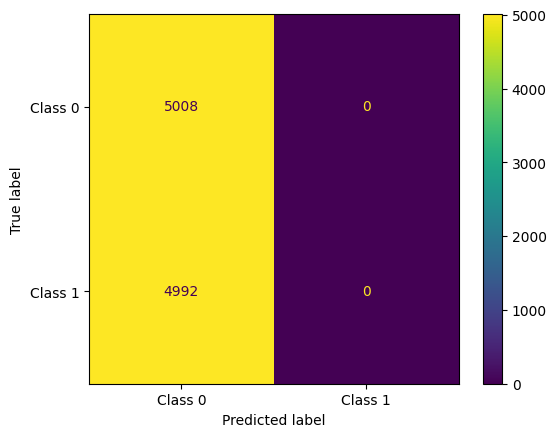

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(true_labels, pred_labels, display_labels=["Class 0", "Class 1"])
plt.show()


In [9]:
dataset['validation']

Dataset({
    features: ['Date', 'Description', 'Comments', 'Check Number', 'Amount', 'Balance', 'rent'],
    num_rows: 10000
})

In [11]:
from scipy.special import softmax

# Convert raw logits to probabilities (values between 0 and 1)
probabilities = softmax(logits, axis=1)

# probability of class 1 (standard for binary classification comparison)
prob_class_1 = probabilities[:, 1] 

In [12]:
from sklearn.metrics import roc_auc_score

# 1. Get the probabilities for the positive class (Class 1)
# Assuming 'probabilities' is your softmax output from the previous step
prob_class_1 = probabilities[:, 1]

# 2. Calculate AUC
auc = roc_auc_score(true_labels, prob_class_1)

# 3. Calculate Gini
gini = 2 * auc - 1

print(f"AUC Score: {auc:.4f}")
print(f"Gini Score: {gini:.4f}")


AUC Score: 0.5025
Gini Score: 0.0051
